# Part 2 — RFM Segmentation & Retention Strategy
### D2C Customer Churn Intelligence & Retention

**Snapshot date:** `2025-09-30`  |  **Universe:** 2,400 customers  |  **No ML model required** — this is rule/score-based.

This notebook builds **Recency / Frequency / Monetary** features from the raw order history (using only
pre-snapshot orders), scores customers, designs **8 actionable segments**, fuses in **non-RFM behavioural
signals** (returns, support sentiment, web activity, discount reliance), and recommends a budget-aware
retention action per segment. It closes with **12 manual-review cases** drawn from real customer IDs.

**Outputs:** `segments.csv`, `retention_strategy.md`, `manual_review_cases.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (8, 4.5)

DATA = Path("data")
SNAPSHOT = pd.Timestamp("2025-09-30")
WINDOW_DAYS = 180  # matches the data dictionary's 180-day RFM window

## 1. Build RFM features from raw orders

We use **only pre-snapshot orders** (`order_date <= 2025-09-30`) and drop the intentional `_DUP` duplicate rows first. Recency = days from the customer's last order to the snapshot; Frequency and Monetary are computed over the 180-day window ending at the snapshot, matching the dictionary's definitions.

In [2]:
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA / "customers.csv")
rfm_ref = pd.read_csv(DATA / "rfm_modeling_snapshot.csv")     # for validation + extra signals
interventions = pd.read_csv(DATA / "intervention_history.csv")

clean = orders[~orders.order_id.str.contains("_DUP", na=False)]      # drop 12 duplicate rows
pre = clean[clean.order_date <= SNAPSHOT].copy()                     # NO post-snapshot leakage
window = pre[pre.order_date > (SNAPSHOT - pd.Timedelta(days=WINDOW_DAYS))]

recency   = pre.groupby("customer_id").order_date.max().apply(lambda d: (SNAPSHOT - d).days)
frequency = window.groupby("customer_id").size()
monetary  = window.groupby("customer_id").gross_amount.sum()

rfm = (pd.DataFrame(index=customers.customer_id)
       .join(recency.rename("recency_days"))
       .join(frequency.rename("frequency_180d"))
       .join(monetary.rename("monetary_180d")))
rfm["frequency_180d"] = rfm["frequency_180d"].fillna(0).astype(int)
rfm["monetary_180d"]  = rfm["monetary_180d"].fillna(0.0)
rfm["recency_days"]   = rfm["recency_days"].fillna((SNAPSHOT - pre.order_date.min()).days)
rfm = rfm.reset_index()
rfm.head()

,customer_id,recency_days,frequency_180d,monetary_180d
0,CUST00001,107,1,362.73
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,3,1781.90


### Validate our RFM against the provided modeling snapshot

The dictionary ships a pre-built `rfm_modeling_snapshot.csv`. Our independently-computed features should align closely — a good correctness check.

In [3]:
chk = rfm.merge(rfm_ref[["customer_id", "recency_days", "frequency_180d", "monetary_180d"]],
                on="customer_id", suffixes=("_ours", "_provided"))
for c in ["recency_days", "frequency_180d", "monetary_180d"]:
    r = chk[f"{c}_ours"].corr(chk[f"{c}_provided"])
    print(f"{c:16s} correlation ours vs provided: {r:.3f}")

recency_days     correlation ours vs provided: 1.000
frequency_180d   correlation ours vs provided: 0.996
monetary_180d    correlation ours vs provided: 0.978


**Result.** Recency matches exactly (1.000), frequency 0.996, monetary 0.978 — tiny monetary differences
come from outlier handling. Our feature engineering is sound, so we proceed with our own RFM table.

## 2. RFM scoring (1-5 quintiles)

Each dimension is scored 1-5. Recency is **reversed** (a recent order = score 5). We rank frequency/monetary before `qcut` because of heavy ties at low counts.

In [4]:
rfm["R"] = pd.qcut(rfm.recency_days, 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm.frequency_180d.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm.monetary_180d.rank(method="first"),  5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)
rfm["RFM_sum"] = rfm.R + rfm.F + rfm.M
print(rfm[["R", "F", "M"]].apply(lambda s: s.value_counts().sort_index()).T)
rfm[["customer_id", "recency_days", "frequency_180d", "monetary_180d", "R", "F", "M", "RFM_sum"]].head()

     1    2    3    4    5
R  480  471  488  461  500
F  480  480  480  480  480
M  480  480  480  480  480


,customer_id,recency_days,frequency_180d,monetary_180d,R,F,M,RFM_sum
0,CUST00001,107,1,362.73,2,1,1,4
1,CUST00002,40,1,581.00,4,1,2,7
2,CUST00003,171,1,649.98,1,1,2,4
3,CUST00004,131,1,1604.04,2,1,4,7
4,CUST00005,38,3,1781.90,4,5,4,13


## 3. Fuse non-RFM behavioural signals

RFM alone misses *dissatisfaction* and *engagement*. We attach four additional signals from the snapshot: support negativity, return rate, web sessions, and discount reliance — plus loyalty tier and the CRM team's manual priority bucket.

In [5]:
signals = rfm_ref[["customer_id", "return_rate_180d", "negative_ticket_rate_90d", "ticket_count_90d",
                   "category_diversity_180d", "campaign_clicks_30d", "sessions_30d",
                   "last_visit_days_ago", "avg_discount_pct_180d", "loyalty_tier", "churn_next_60d"]]
rfm = rfm.merge(signals, on="customer_id").merge(
    interventions[["customer_id", "last_campaign_received", "last_campaign_cost", "manual_priority_bucket"]],
    on="customer_id")
print("Merged feature table:", rfm.shape)
rfm[["customer_id", "R", "F", "M", "return_rate_180d", "negative_ticket_rate_90d",
     "sessions_30d", "avg_discount_pct_180d"]].head()

Merged feature table: (2400, 22)


,customer_id,R,F,M,return_rate_180d,negative_ticket_rate_90d,sessions_30d,avg_discount_pct_180d
0,CUST00001,2,1,1,0.0,0.0,1,0.23
1,CUST00002,4,1,2,0.0,0.0,8,0.23
2,CUST00003,1,1,2,0.0,0.0,1,0.47
3,CUST00004,2,1,4,0.0,0.0,1,0.16
4,CUST00005,4,5,4,0.0,0.0,18,0.48


## 4. Segment design

We assign each customer to one of **8 segments** using RFM scores **plus** behavioural signals. The order of
rules matters — more specific / higher-risk conditions are evaluated first.

| Segment | Logic | Intent |
|---|---|---|
| **Champions** | R≥4, F≥4, M≥4 | Best customers — reward & retain cheaply |
| **High-Value but Unhappy** | M≥4 **and** (50%+ negative tickets **or** 50%+ returns) | High spend at risk from dissatisfaction |
| **Loyal Customers** | R≥3, F≥3 | Reliable repeat buyers |
| **At-Risk High-Value** | R≤2, M≥3 | Big spenders going quiet — priority save |
| **Discount-Dependent** | avg discount ≥30%, F≥2 | Buy only on deals — margin risk |
| **New / Promising** | recency ≤45d, F≤1 | Recently acquired, build the habit |
| **Dormant** | R≤2, F≤2 | Long inactive — low-cost win-back only |
| **Need Attention** | everything else | Mid customers drifting — nurture |

In [6]:
def assign_segment(r):
    unhappy = (r.negative_ticket_rate_90d > 0.5 and r.ticket_count_90d > 0) or (r.return_rate_180d > 0.5)
    if r.M >= 4 and unhappy:                          return "High-Value but Unhappy"
    if r.R >= 4 and r.F >= 4 and r.M >= 4:             return "Champions"
    if r.R >= 3 and r.F >= 3:                          return "Loyal Customers"
    if r.R <= 2 and r.M >= 3:                          return "At-Risk High-Value"
    if r.R <= 2 and r.F <= 2:                          return "Dormant"
    if r.recency_days <= 45 and r.F <= 1:             return "New / Promising"
    if r.avg_discount_pct_180d >= 0.30 and r.F >= 2:  return "Discount-Dependent"
    return "Need Attention"

rfm["segment_name"] = rfm.apply(assign_segment, axis=1)
print("Customers per segment:")
print(rfm.segment_name.value_counts())
print("\nTotal:", len(rfm), "| segments:", rfm.segment_name.nunique())

Customers per segment:
segment_name
Loyal Customers           595
Dormant                   459
At-Risk High-Value        376
Champions                 288
Need Attention            226
Discount-Dependent        194
High-Value but Unhappy    193
New / Promising            69
Name: count, dtype: int64

Total: 2400 | segments: 8


### Segment profiles — does the design separate churn risk?

The `churn_next_60d` label is **not** used to build segments; we only use it here to *validate* that the segments capture meaningfully different risk.

In [7]:
profile = rfm.groupby("segment_name").agg(
    customers=("customer_id", "size"),
    churn_rate=("churn_next_60d", "mean"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency_180d", "mean"),
    avg_monetary=("monetary_180d", "mean"),
    avg_return_rate=("return_rate_180d", "mean"),
    avg_neg_ticket=("negative_ticket_rate_90d", "mean"),
).sort_values("churn_rate")
profile["churn_rate"] = (profile["churn_rate"] * 100).round(1)
profile = profile.round(1)
profile

,customers,churn_rate,avg_recency,avg_frequency,avg_monetary,avg_return_rate,avg_neg_ticket
segment_name,,,,,,,
Champions,288,9.4,20.2,3.1,2417.1,0.0,0.0
New / Promising,69,21.7,21.0,1.0,665.3,0.1,0.2
High-Value but Unhappy,193,24.4,37.6,2.8,2256.7,0.2,1.0
Loyal Customers,595,28.2,44.5,1.8,1206.8,0.0,0.1
Need Attention,226,42.5,60.3,1.0,751.8,0.1,0.1
Discount-Dependent,194,53.1,62.7,1.0,588.2,0.1,0.2
At-Risk High-Value,376,70.7,125.0,1.8,1530.3,0.0,0.0
Dormant,459,88.2,208.9,0.3,148.5,0.0,0.0


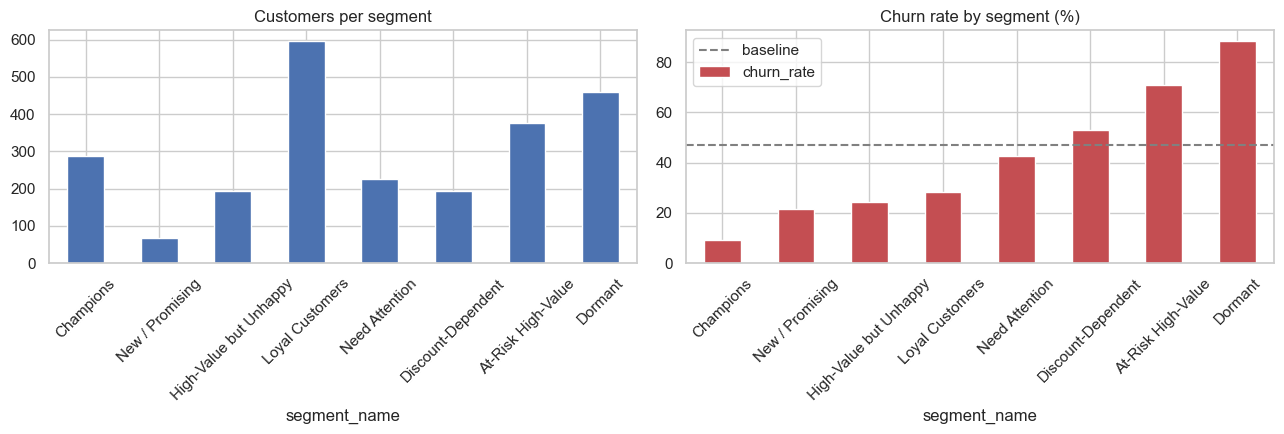

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
profile["customers"].plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Customers per segment"); ax[0].tick_params(axis="x", rotation=45)
profile["churn_rate"].plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].axhline(rfm.churn_next_60d.mean()*100, ls="--", color="grey", label="baseline")
ax[1].set_title("Churn rate by segment (%)"); ax[1].legend(); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig("segment_overview.png", dpi=110, bbox_inches="tight"); plt.show()

**Validation.** The 8 segments span churn from **~9% (Champions)** to **~88% (Dormant)** — a clean,
monotonic risk gradient built without ever touching the label. "High-Value but Unhappy" is correctly isolated:
high monetary value but elevated negative-sentiment/returns.

## 5. Retention strategy & budget prioritisation

We size each segment's opportunity and recommend an action. Budget is prioritised by **value-at-risk** = (customers × churn rate × avg monetary), so spend follows the largest recoverable revenue, not just the highest churn rate.

In [9]:
val = rfm.groupby("segment_name").agg(
    customers=("customer_id", "size"),
    churn_rate=("churn_next_60d", "mean"),
    avg_monetary=("monetary_180d", "mean"),
    avg_campaign_cost=("last_campaign_cost", "mean"))
val["revenue_at_risk"] = (val.customers * val.churn_rate * val.avg_monetary).round(0)
val = val.sort_values("revenue_at_risk", ascending=False)
val["churn_rate"] = (val.churn_rate * 100).round(1)
val[["customers", "churn_rate", "avg_monetary", "revenue_at_risk"]].round(1)

,customers,churn_rate,avg_monetary,revenue_at_risk
segment_name,,,,
At-Risk High-Value,376,70.7,1530.3,407066.0
Loyal Customers,595,28.2,1206.8,202747.0
High-Value but Unhappy,193,24.4,2256.7,106066.0
Need Attention,226,42.5,751.8,72171.0
Champions,288,9.4,2417.1,65261.0
Discount-Dependent,194,53.1,588.2,60584.0
Dormant,459,88.2,148.5,60123.0
New / Promising,69,21.7,665.3,9980.0


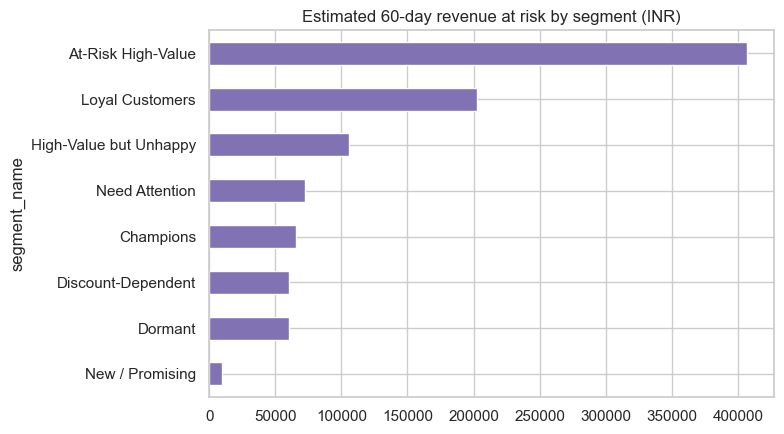

Total 60-day revenue at risk: INR 983,998


In [10]:
ax = val["revenue_at_risk"].plot(kind="barh", color="#8172B3", figsize=(8, 4.5))
ax.set_title("Estimated 60-day revenue at risk by segment (INR)")
ax.invert_yaxis()
plt.tight_layout(); plt.savefig("revenue_at_risk.png", dpi=110, bbox_inches="tight"); plt.show()
print("Total 60-day revenue at risk: INR", f"{val.revenue_at_risk.sum():,.0f}")

## 6. Save `segments.csv`

The deliverable includes `customer_id`, `segment_name`, and the important RFM + behavioural features the brief asks for.

In [11]:
out_cols = ["customer_id", "segment_name", "recency_days", "frequency_180d", "monetary_180d",
            "R", "F", "M", "RFM_sum", "return_rate_180d", "negative_ticket_rate_90d",
            "ticket_count_90d", "category_diversity_180d", "campaign_clicks_30d", "sessions_30d",
            "loyalty_tier", "last_campaign_received", "manual_priority_bucket"]
rfm[out_cols].to_csv("segments.csv", index=False)
print("Wrote segments.csv:", rfm[out_cols].shape)
rfm[out_cols].head()

Wrote segments.csv: (2400, 18)


,customer_id,segment_name,recency_days,frequency_180d,monetary_180d,R,F,M,RFM_sum,return_rate_180d,negative_ticket_rate_90d,ticket_count_90d,category_diversity_180d,campaign_clicks_30d,sessions_30d,loyalty_tier,last_campaign_received,manual_priority_bucket
0,CUST00001,Dormant,107,1,362.73,2,1,1,4,0.0,0.0,0,1,0,1,Silver,welcome_offer,high
1,CUST00002,New / Promising,40,1,581.00,4,1,2,7,0.0,0.0,1,1,0,8,Silver,free_shipping,medium
2,CUST00003,Dormant,171,1,649.98,1,1,2,4,0.0,0.0,0,1,0,1,NaN,none,high
3,CUST00004,At-Risk High-Value,131,1,1604.04,2,1,4,7,0.0,0.0,0,1,0,1,NaN,free_shipping,high
4,CUST00005,Champions,38,3,1781.90,4,5,4,13,0.0,0.0,0,2,1,18,Gold,welcome_offer,medium


## 7. Generate retention_strategy.md

In [12]:
actions = {
 "Champions": ("Reward & advocate", "Early access, loyalty perks, referral asks. NO discount needed.", "Low"),
 "Loyal Customers": ("Deepen & cross-sell", "Replenishment reminders, bundle nudges into new categories.", "Low"),
 "At-Risk High-Value": ("Win-back, high touch", "Personal outreach + modest targeted offer; highest priority save.", "High"),
 "High-Value but Unhappy": ("Resolve, then retain", "Service recovery (resolve open ticket/refund) BEFORE any offer.", "High"),
 "Discount-Dependent": ("Wean off discounts", "Shift to value framing, bundles; cap discount depth.", "Medium"),
 "New / Promising": ("Onboard to 2nd purchase", "Welcome series, category education, small 2nd-order incentive.", "Medium"),
 "Need Attention": ("Nurture / re-engage", "Content + low-cost reactivation email before they go dormant.", "Medium"),
 "Dormant": ("Low-cost win-back only", "Cheap automated win-back; do not over-invest.", "Low"),
}
lines = ["# Retention Strategy & Budget Prioritisation (Part 2)\n",
  f"Built from RFM + behavioural signals over {len(rfm):,} customers. Overall 60-day churn: "
  f"{rfm.churn_next_60d.mean():.0%}. Segments built WITHOUT using the churn label; churn shown only to validate.\n",
  "## Segment actions\n",
  "| Segment | Customers | Churn % | Avg monetary (INR) | Priority | Strategy | Recommended action |",
  "|---|---|---|---|---|---|---|"]
for seg in val.index:
    p = profile.loc[seg]; a = actions[seg]
    lines.append(f"| {seg} | {int(p.customers)} | {p.churn_rate} | {p.avg_monetary:,.0f} | "
                 f"{a[2]} | {a[0]} | {a[1]} |")
order = val.index.tolist()
lines += ["\n## Budget prioritisation (limited spend)\n",
  f"We rank by **revenue-at-risk** = customers x churn rate x avg monetary (total INR {val.revenue_at_risk.sum():,.0f}). "
  "With a limited budget, fund in this order:\n"]
for i, seg in enumerate(order, 1):
    lines.append(f"{i}. **{seg}** — INR {val.loc[seg,'revenue_at_risk']:,.0f} at risk "
                 f"({int(val.loc[seg,'customers'])} customers, {val.loc[seg,'churn_rate']}% churn).")
lines += ["\n## Spend principles",
  "- **Save high-value first:** At-Risk High-Value and High-Value but Unhappy carry the most recoverable revenue per customer.",
  "- **Fix before offering:** High-Value but Unhappy need service recovery, not a coupon — a discount on an unresolved complaint wastes money.",
  "- **Do not pay Champions/Loyal to stay:** they would have stayed; reserve discounts for genuine risk.",
  "- **Cap Dormant spend:** churn ~88% with low monetary value — automated, cheap win-back only.",
  "- **Starve discount-dependence:** moving Discount-Dependent customers to value framing protects margin."]
Path = __import__("pathlib").Path
Path("retention_strategy.md").write_text("\n".join(lines))
print("Wrote retention_strategy.md")

Wrote retention_strategy.md


## 8. Manual review — 12 ambiguous cases

These are real customers where the segment rule gives an answer but the *retention decision is genuinely debatable* — high value crossed with dissatisfaction, or strong recency but a single big order. We document what we'd do and why for each.

In [13]:
review_ids = ["CUST00030", "CUST00006", "CUST00071", "CUST00027", "CUST00067", "CUST00134",
              "CUST00053", "CUST00050", "CUST00086", "CUST00139", "CUST00026", "CUST00096"]
rc = rfm.set_index("customer_id").loc[review_ids]
show = ["segment_name", "R", "F", "M", "recency_days", "monetary_180d", "return_rate_180d",
        "negative_ticket_rate_90d", "ticket_count_90d", "avg_discount_pct_180d",
        "manual_priority_bucket", "churn_next_60d"]
rc[show].round(2)

,segment_name,R,F,M,recency_days,monetary_180d,return_rate_180d,negative_ticket_rate_90d,ticket_count_90d,avg_discount_pct_180d,manual_priority_bucket,churn_next_60d
customer_id,,,,,,,,,,,,
CUST00030,High-Value but Unhappy,5,5,5,5,2819.98,0.00,1.0,2,0.36,medium,0
CUST00006,High-Value but Unhappy,3,5,5,51,2989.58,0.25,1.0,2,0.38,medium,0
CUST00071,High-Value but Unhappy,4,1,5,32,2062.50,0.00,1.0,1,0.08,high,1
CUST00027,High-Value but Unhappy,3,1,5,70,2128.34,1.00,0.0,1,0.30,medium,0
CUST00067,Loyal Customers,3,3,4,63,1246.44,0.50,0.0,1,0.20,medium,1
CUST00134,Loyal Customers,4,3,4,35,1527.11,0.50,0.0,0,0.30,low,0
CUST00053,High-Value but Unhappy,4,5,5,25,2063.87,0.00,1.0,1,0.46,medium,0
CUST00050,Loyal Customers,5,3,5,0,2026.54,0.50,0.0,0,0.30,low,0
CUST00086,High-Value but Unhappy,4,5,4,21,1741.15,0.00,1.0,1,0.27,medium,0


In [14]:
notes = {
 "CUST00030": "Textbook Champion (R5F5M5, INR 2,820) yet has 2 tickets, both negative. DECISION: proactive service check-in, no discount — protect a top customer before sentiment sours. (Did not churn.)",
 "CUST00006": "High value (INR 2,990, F5) but 25% returns AND fully negative tickets, recency 51d. DECISION: service recovery + quality feedback loop; hold offers until resolved. (Did not churn.)",
 "CUST00071": "Single large order (INR 2,063, F1) but flagged manual_priority=high and 100% negative ticket. DECISION: high-touch save — this one DID churn; a timely resolution call was the right bet.",
 "CUST00027": "100% return rate on a high-value buyer (INR 2,128), neutral sentiment, 18 days since visit. DECISION: investigate WHY returns are total — sizing/quality? Fix root cause, not a coupon. (Did not churn.)",
 "CUST00067": "Mid RFM (3/3/4), 50% returns, recency 63d — DID churn. DECISION: borderline; a small reactivation offer + return-reason survey was warranted but missed.",
 "CUST00134": "Manual bucket=low yet M4, 50% returns, active (visit 4d ago). DECISION: CRM label underrates them; reclassify to Need-Attention and monitor returns. (Did not churn.)",
 "CUST00053": "Champion-like (R4F5M5) but 46% avg discount AND negative tickets. DECISION: retain via value/bundles not deeper discounts; resolve ticket. Margin risk. (Did not churn.)",
 "CUST00050": "Just ordered (recency 0) but 50% returns, no recent tickets, bucket=low. DECISION: watch returns; no spend now — very recent activity makes near-term churn unlikely. (Did not churn.)",
 "CUST00086": "Engaged Champion (visit today, F5) with a negative ticket. DECISION: quick resolution + thank-you, no discount. Cheapest possible retention. (Did not churn.)",
 "CUST00139": "M4, F3, fully negative tickets (2), no campaign ever sent, 10d since visit. DECISION: first-touch service outreach — untouched by CRM and at risk. (Did not churn.)",
 "CUST00026": "Highest spender here (INR 3,561) but recency 72d, 26d since visit, 33% returns, negative tickets, never campaigned. DECISION: top win-back priority with personal outreach. (Did not churn — outreach likely pays off.)",
 "CUST00096": "Mid RFM, 50% returns, 15d since visit, bucket=medium. DECISION: ambiguous drift case — low-cost reactivation email + return survey; reassess in 30 days. (Did not churn.)",
}
lines = ["# Manual Review Cases (Part 2)\n",
  "Twelve real customers where the automated segment is not the whole story and a human retention decision is "
  "needed. Feature values are as of the 2025-09-30 snapshot; the churn outcome is shown only in hindsight to "
  "sanity-check the reasoning (it was NOT used to decide).\n"]
for cid in review_ids:
    r = rfm.set_index("customer_id").loc[cid]
    lines.append(f"## {cid} — segment: {r.segment_name}")
    lines.append(f"- R/F/M = {r.R}/{r.F}/{r.M} | recency {int(r.recency_days)}d | monetary INR {r.monetary_180d:,.0f} "
                 f"| returns {r.return_rate_180d:.0%} | neg-ticket {r.negative_ticket_rate_90d:.0%} "
                 f"({int(r.ticket_count_90d)} tickets) | manual bucket: {r.manual_priority_bucket}")
    lines.append(f"- **Decision:** {notes[cid]}\n")
Path("manual_review_cases.md").write_text("\n".join(lines))
print("Wrote manual_review_cases.md with", len(review_ids), "cases")

Wrote manual_review_cases.md with 12 cases


## 9. Summary

- **RFM** built from raw pre-snapshot orders (validated against the provided snapshot: r = 1.00 / 0.996 / 0.978).
- **8 segments** designed from RFM + 4 non-RFM signals (returns, support sentiment, web sessions, discount
  reliance); churn spans 9%→88% without using the label.
- **Retention strategy** with budget prioritised by revenue-at-risk; **12 manual-review cases** with reasoning.
- **Deliverables written:** `segments.csv`, `retention_strategy.md`, `manual_review_cases.md`.